<a href="https://colab.research.google.com/github/sowmyasameer4/ML-DL-Projects/blob/main/Cervical_Cancer/PROJECT(5)(Cervical_Cancer).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

Cervical cancer is one of the most common cancers affecting women worldwide and remains a major public health concern, particularly in developing countries. Early detection and timely diagnosis are crucial for improving survival rates and reducing the mortality associated with the disease. However, identifying individuals who are at high risk can be difficult because cervical cancer is influenced by multiple factors such as age, lifestyle habits, reproductive history, smoking, use of contraceptives, and the presence of sexually transmitted diseases (STDs).

With the increasing availability of healthcare data, machine learning techniques can be used to analyze complex medical datasets and identify patterns that may not be easily detected through traditional methods. By analyzing patient risk factors and medical history, predictive models can be developed to estimate the likelihood of cervical cancer occurrence.

Target Variable:
Biopsy

0 → No Cancer

1 → Cancer Detected

The aim of this project is to analyze cervical cancer risk factor data and develop a machine learning model that can predict whether a patient is likely to have cervical cancer based on these factors. This prediction can assist healthcare professionals in early diagnosis and decision-making


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/cervical_cancer_dataset.csv")
df

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,38,3.0,18.0,4.0,0.0,0.0,0.000000,1.0,10.000000,1.0,...,NaN,NaN,0,0,0,0,0,1,1,1
1,18,3.0,17.0,1.0,1.0,6.0,1.200000,0.0,0.000000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,24,3.0,14.0,2.0,0.0,0.0,0.000000,0.0,0.000000,1.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,33,5.0,19.0,1.0,1.0,4.0,0.513202,1.0,2.282201,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
4,34,2.0,21.0,2.0,0.0,0.0,0.000000,1.0,0.330000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,18,3.0,14.0,2.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,NaN,NaN,0,0,0,0,0,0,1,0
99996,36,1.0,17.0,4.0,0.0,0.0,0.000000,1.0,0.250000,1.0,...,NaN,NaN,0,0,0,0,0,0,0,0
99997,35,5.0,15.0,4.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
99998,35,3.0,17.0,3.0,1.0,9.0,2.700000,1.0,17.000000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Age                                 100000 non-null  int64  
 1   Number of sexual partners           97050 non-null   float64
 2   First sexual intercourse            99211 non-null   float64
 3   Num of pregnancies                  93341 non-null   float64
 4   Smokes                              98394 non-null   float64
 5   Smokes (years)                      98394 non-null   float64
 6   Smokes (packs/year)                 98394 non-null   float64
 7   Hormonal Contraceptives             87468 non-null   float64
 8   Hormonal Contraceptives (years)     87468 non-null   float64
 9   IUD                                 86318 non-null   float64
 10  IUD (years)                         86318 non-null   float64
 11  STDs                       

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,2950
First sexual intercourse,789
Num of pregnancies,6659
Smokes,1606
Smokes (years),1606
Smokes (packs/year),1606
Hormonal Contraceptives,12532
Hormonal Contraceptives (years),12532
IUD,13682


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
99995,True
99996,True
99997,True
99998,True


In [ ]:
df.drop(["STDs: Time since first diagnosis","STDs: Time since last diagnosis"],axis=1, inplace=True)

In [ ]:
df.dropna(subset=['STDs:HPV','STDs:Hepatitis B','STDs:HIV','STDs:AIDS','STDs:molluscum contagiosum','STDs:genital herpes','STDs:pelvic inflammatory disease','STDs:syphilis','STDs:vulvo-perineal condylomatosis','STDs:vaginal condylomatosis','STDs:cervical condylomatosis','STDs:condylomatosis','STDs (number)','STDs','IUD (years)','IUD','Hormonal Contraceptives (years)','Hormonal Contraceptives'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,1609
First sexual intercourse,670
Num of pregnancies,4779
Smokes,1017
Smokes (years),1017
Smokes (packs/year),1017
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [ ]:
df.shape

(85463, 34)

### Null values filling with mode(Descrete values)

In [ ]:
df['Number of sexual partners'].fillna(df['Number of sexual partners'].mode()[0], inplace=True)

/tmp/ipykernel_222/846510068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Number of sexual partners'].fillna(df['Number of sexual partners'].mode()[0], inplace=True)


In [ ]:
df['First sexual intercourse'].fillna(df['First sexual intercourse'].mode()[0], inplace=True)

/tmp/ipykernel_222/3492736933.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['First sexual intercourse'].fillna(df['First sexual intercourse'].mode()[0], inplace=True)


In [ ]:
df['Num of pregnancies'].fillna(df['Num of pregnancies'].mode()[0], inplace=True)

/tmp/ipykernel_222/4105201325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Num of pregnancies'].fillna(df['Num of pregnancies'].mode()[0], inplace=True)


In [ ]:
df['Smokes'].fillna(df['Smokes'].mode()[0], inplace=True)

/tmp/ipykernel_222/1390970946.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Smokes'].fillna(df['Smokes'].mode()[0], inplace=True)


In [ ]:
df.head(1)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,38,3.0,18.0,4.0,0.0,0.0,0.0,1.0,10.0,1.0,...,0.0,0,0,0,0,0,0,1,1,1


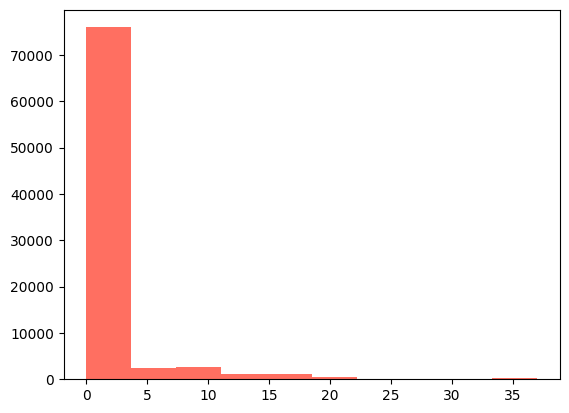

In [ ]:
plt.hist(df["Smokes (years)"], color='#ff6f61') #continuos data fill with median (normal curve-fill with mean)
plt.show()

In [ ]:
df['Smokes (years)'].fillna(df['Smokes (years)'].mean(), inplace=True)

/tmp/ipykernel_222/3598523593.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Smokes (years)'].fillna(df['Smokes (years)'].mean(), inplace=True)


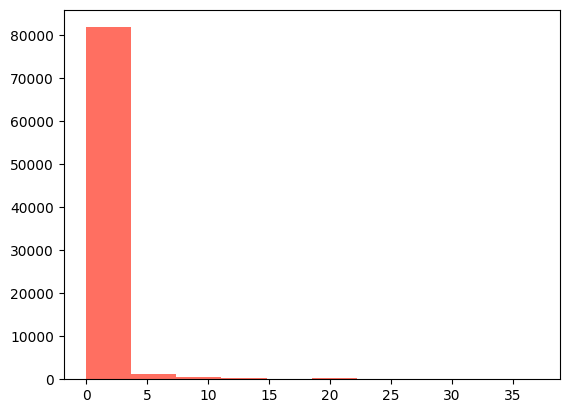

In [ ]:
plt.hist(df["Smokes (packs/year)"], color='#ff6f61')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85463 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 85463 non-null  int64  
 1   Number of sexual partners           85463 non-null  float64
 2   First sexual intercourse            85463 non-null  float64
 3   Num of pregnancies                  85463 non-null  float64
 4   Smokes                              85463 non-null  float64
 5   Smokes (years)                      85463 non-null  float64
 6   Smokes (packs/year)                 84446 non-null  float64
 7   Hormonal Contraceptives             85463 non-null  float64
 8   Hormonal Contraceptives (years)     85463 non-null  float64
 9   IUD                                 85463 non-null  float64
 10  IUD (years)                         85463 non-null  float64
 11  STDs                                85463 non-

In [ ]:
df['Smokes (packs/year)'] = pd.to_numeric(df['Smokes (packs/year)'], errors='coerce')
df['Smokes (packs/year)'].fillna(df['Smokes (packs/year)'].mean(), inplace=True)

/tmp/ipykernel_222/2357651950.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Smokes (packs/year)'].fillna(df['Smokes (packs/year)'].mean(), inplace=True)


## **Visualization**

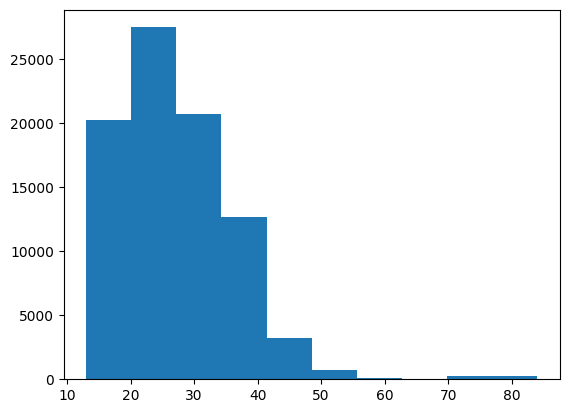

In [ ]:
plt.hist(df["Age"])
plt.show()

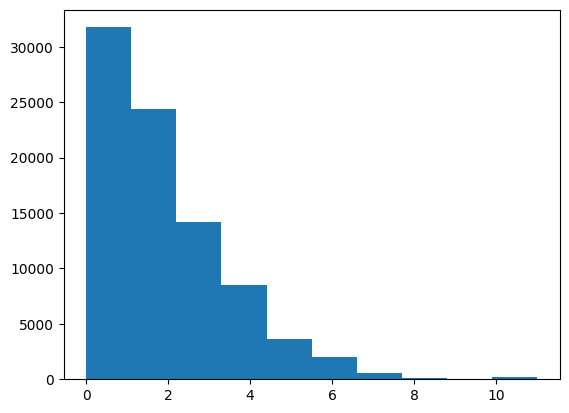

In [ ]:
plt.hist(df["Num of pregnancies"])
plt.show()

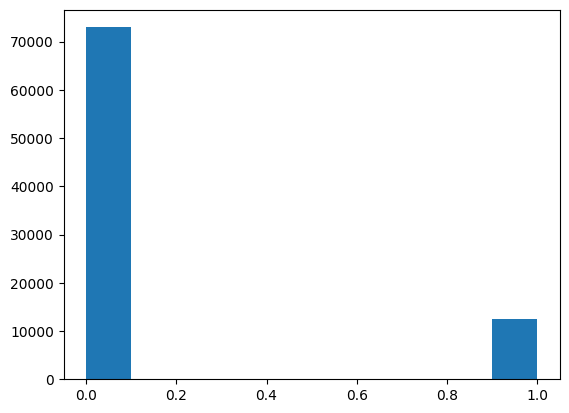

In [ ]:
plt.hist(df["Smokes"])
plt.show()

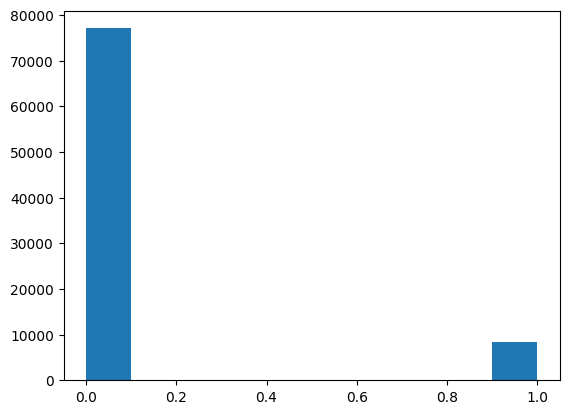

In [ ]:
plt.hist(df["STDs"])
plt.show()

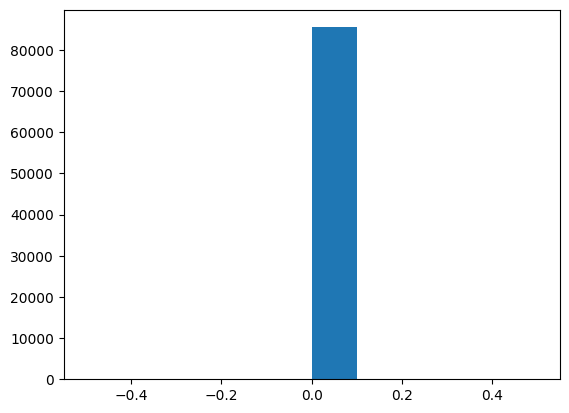

In [ ]:
plt.hist(df["STDs:AIDS"])
plt.show()

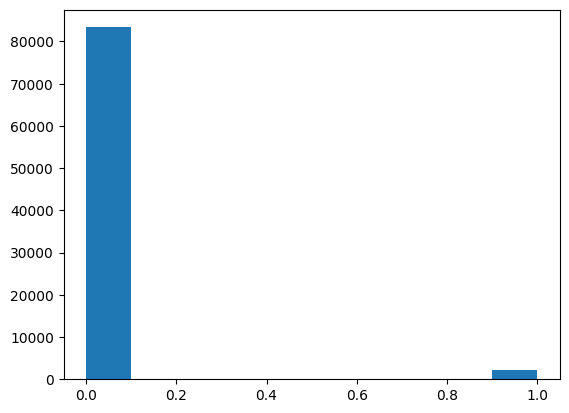

In [ ]:
plt.hist(df["Dx:Cancer"])
plt.show()

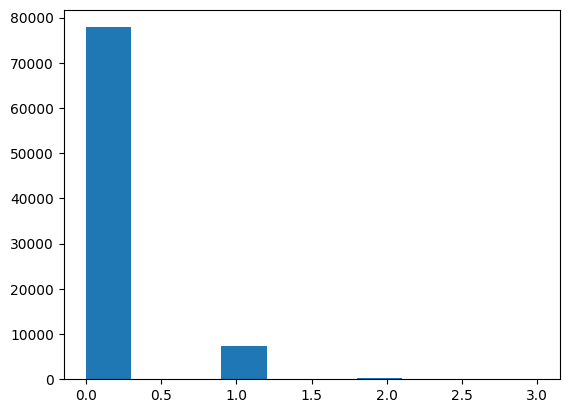

In [ ]:
plt.hist(df["STDs: Number of diagnosis"])
plt.show()

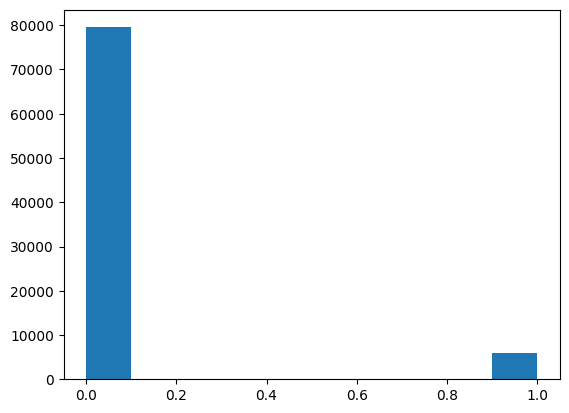

In [ ]:
plt.hist(df["Biopsy"])
plt.show()

## Over Sampling Using SMOTE because of Imbalanced Target

In [ ]:
from imblearn.over_sampling import SMOTE

x = df.drop("Biopsy", axis=1)
y = df["Biopsy"]

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x,y)

In [ ]:
df_smote = x_resampled.copy()
df_smote["Biopsy"] = y_resampled

array([[<Axes: title={'center': 'Biopsy'}>]], dtype=object)

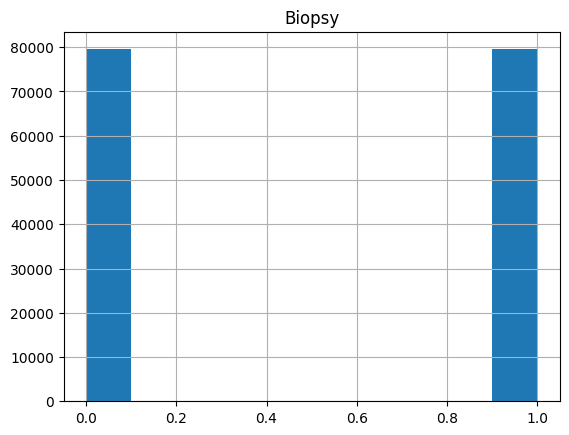

In [ ]:
df_smote.hist("Biopsy")

In [ ]:
df = df_smote

## **Correlation**

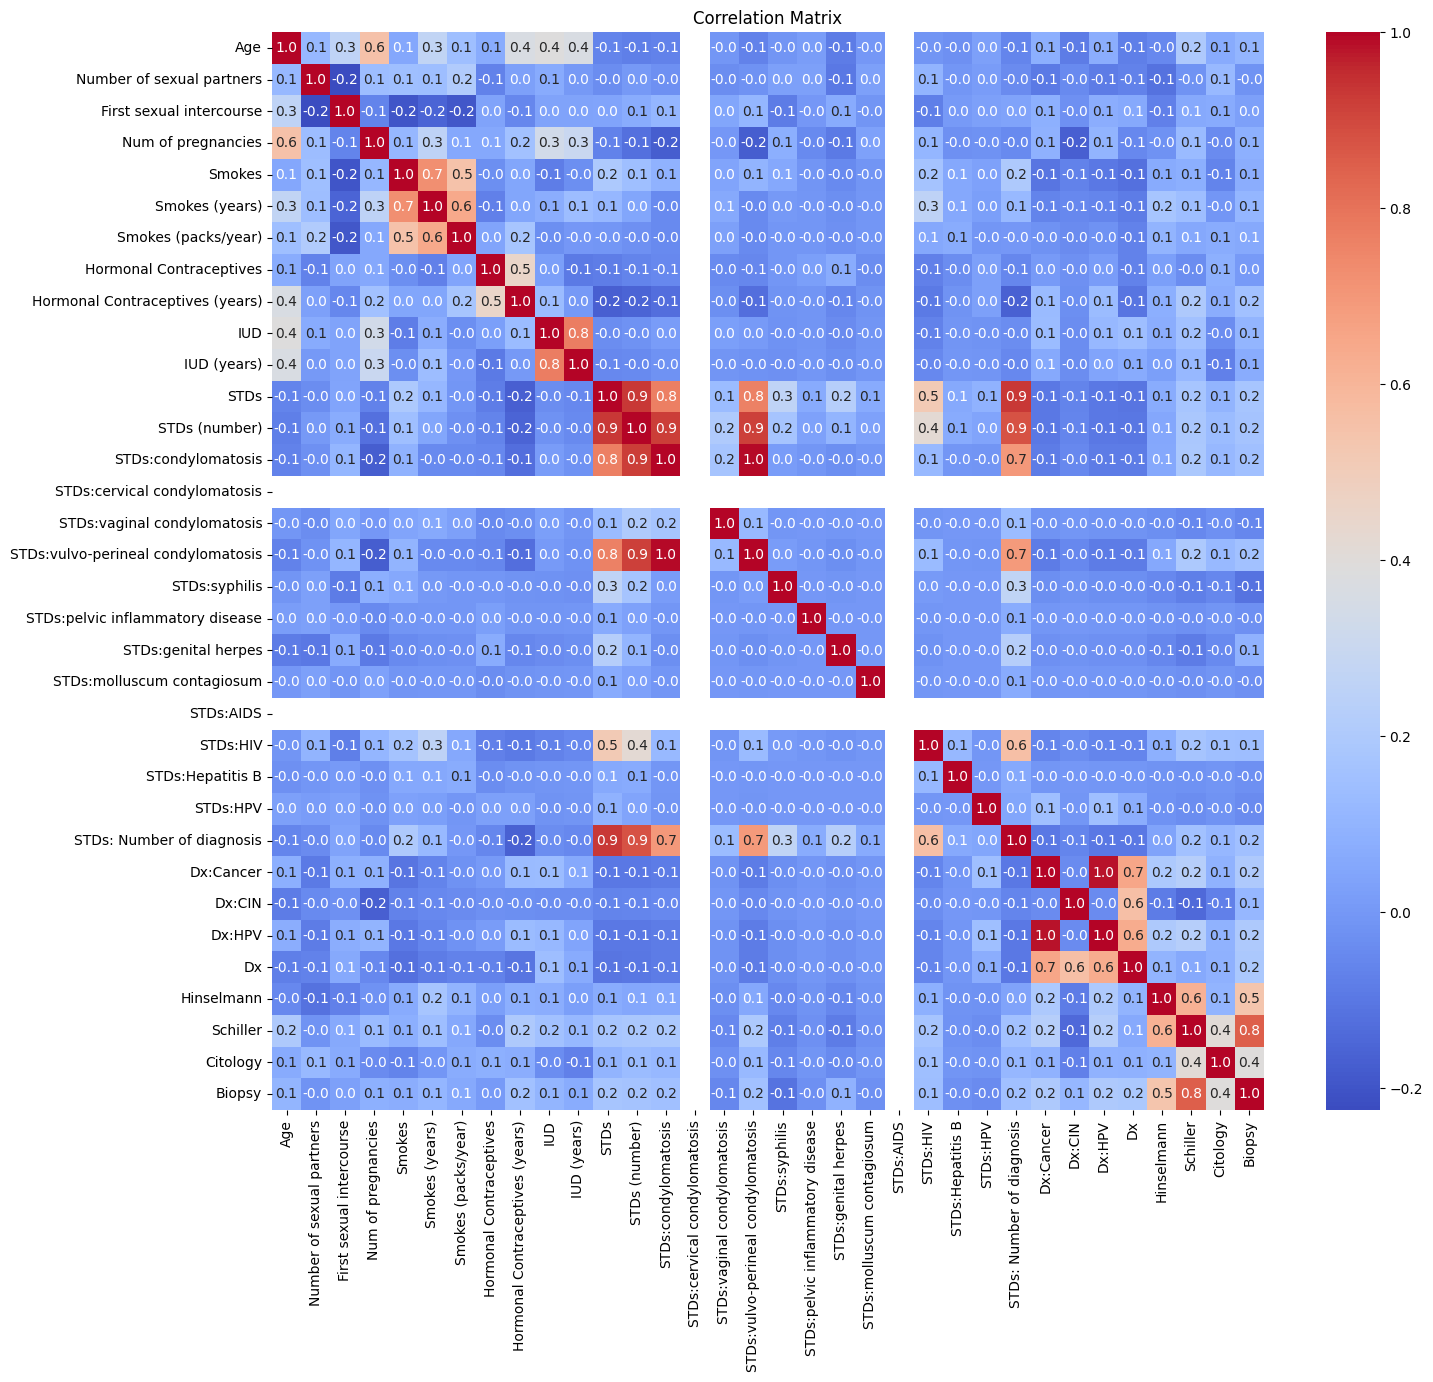

In [ ]:
plt.figure(figsize=(16,14))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')

plt.show()

In [ ]:
df['STDs:AIDS'].unique() #checking unique value,Bcz of blank space in correlation matrix

array([0.])

In [ ]:
df['STDs:cervical condylomatosis'].unique()

array([0.])

In [ ]:
df.drop(['STDs:AIDS','STDs:cervical condylomatosis'], axis=1,inplace=True) #Bcz it has only one value

In [ ]:
df.drop(['STDs','STDs (number)','IUD (years)'],axis=1,inplace=True) #removing high correlated values

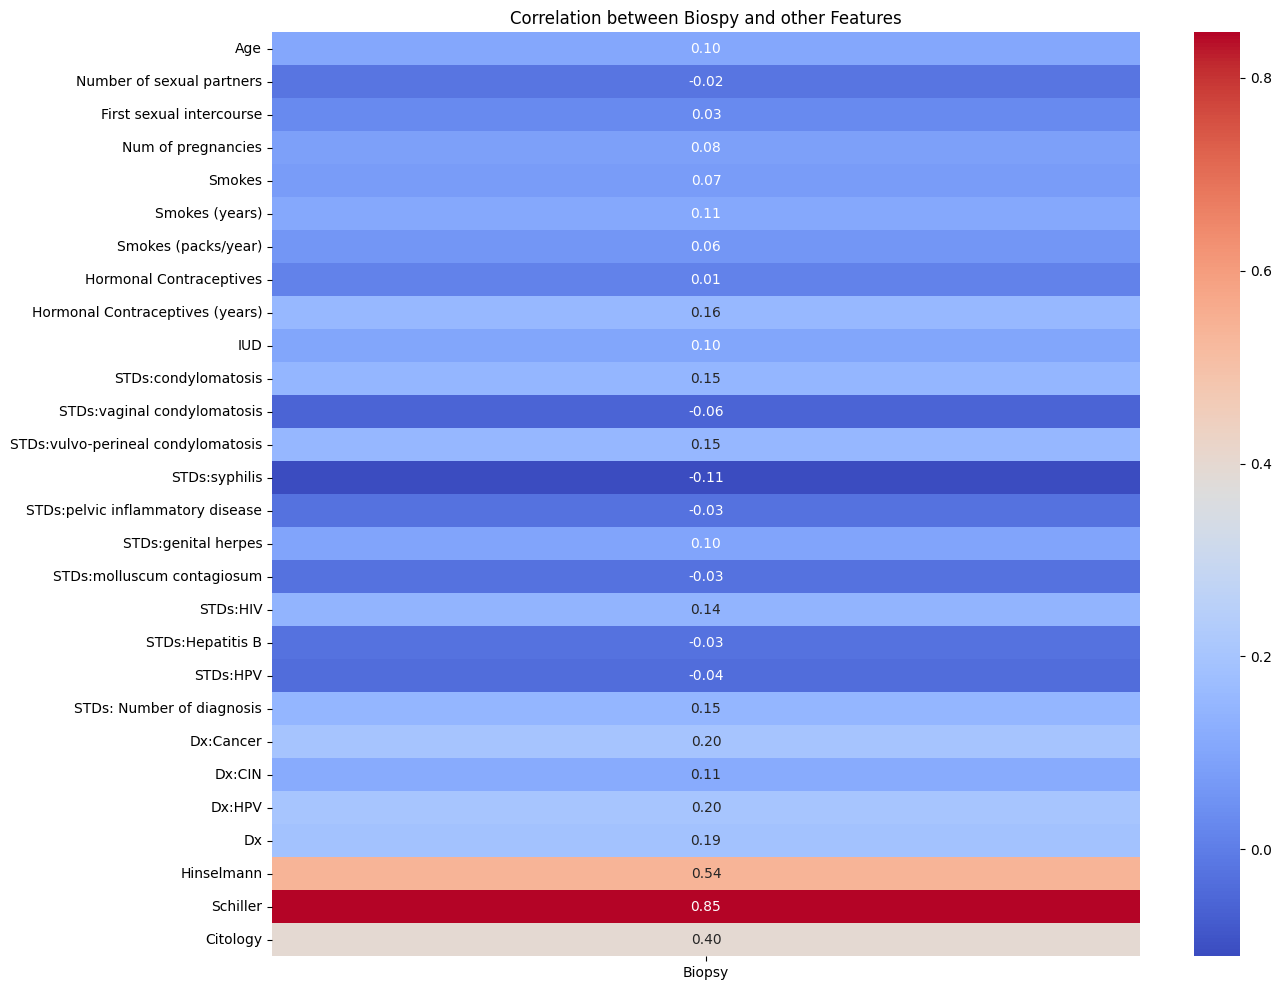

In [ ]:
plt.figure(figsize=(14,12))
Biopsy_corr = df.corr()['Biopsy']

Biopsy_corr = Biopsy_corr.drop('Biopsy')

sns.heatmap(Biopsy_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True, annot_kws={'size':10})
plt.title('Correlation between Biospy and other Features')
plt.show()


In [ ]:
df.drop(["Age","Number of sexual partners","First sexual intercourse","Num of pregnancies","Smokes","Smokes (years)","Smokes (packs/year)","Hormonal Contraceptives","Hormonal Contraceptives (years)","IUD","STDs:condylomatosis","STDs:vaginal condylomatosis","STDs:vulvo-perineal condylomatosis","STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes","STDs:molluscum contagiosum","STDs:HIV","STDs:Hepatitis B","STDs: Number of diagnosis","Dx:CIN","Dx"],axis=1,inplace=True)

## **Outlier cheking and removing**

<Axes: >

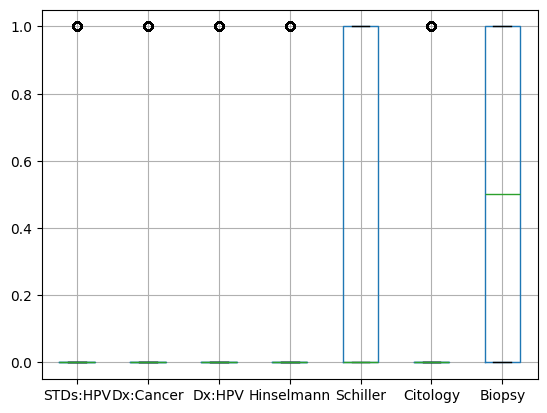

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:
    if col == exclude_column:
      continue

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower_bound = q1-1.5 * IQR
    upper_bound = q3+1.5 * IQR
    df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

df_cleaned = remove_outliers_iqr(df, exclude_column='Biopsy') # Corrected typo here
df=df_cleaned

In [ ]:
df.shape

(96993, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96993 entries, 1 to 159059
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   STDs:HPV    96993 non-null  float64
 1   Dx:Cancer   96993 non-null  int64  
 2   Dx:HPV      96993 non-null  int64  
 3   Hinselmann  96993 non-null  int64  
 4   Schiller    96993 non-null  int64  
 5   Citology    96993 non-null  int64  
 6   Biopsy      96993 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 5.9 MB


## Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x = df[['STDs:HPV','Dx:Cancer','Dx:HPV','Hinselmann','Schiller','Citology']]
y = df['Biopsy']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model Accuracy: {accuracy:.2f}')

Baseline Model Accuracy: 0.91


## k-fold

In [ ]:
from sklearn.model_selection import KFold

x=df.drop('Biopsy',axis=1)
y=df['Biopsy']

kf = KFold(n_splits=5,shuffle=True, random_state=42)
model = LogisticRegression()

best_accuracy = 0
best_fold = -1

best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(x),1):
  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  model.fit(x_train, y_train)


  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"Fold {fold} Accuracy: {acc}")

  if acc > best_accuracy:
    best_accuracy = acc
    best_folr = fold
    best_x_train = x_train
    best_y_train = y_train
    best_x_test = x_test
    best_y_test = y_test
    best_y_pred = y_pred

print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1 Accuracy: 0.9055105933295531
Fold 2 Accuracy: 0.9063869271611938
Fold 3 Accuracy: 0.9022630032475901
Fold 4 Accuracy: 0.9064336529539128
Fold 5 Accuracy: 0.900659861841427

 Best Fold: -1 with Accuracy: 0.9064336529539128


## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)



0.9064336529539128

## **SVC**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svclassifier = SVC()
svclassifier.fit(best_x_train,best_y_train)

y_pred = svclassifier.predict(best_x_test)
accuracy = accuracy_score(best_y_test, y_pred)
print(f'SVC model accuracy (best fold): {accuracy:.2f}')

SVC model accuracy (best fold): 0.91


## **XGBoost**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)

0.9064336529539128

## **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

y_pred = model.predict(best_x_test)

cm = confusion_matrix(best_y_test, y_pred)
print(cm)

[[14631   306]
 [ 1509  2952]]


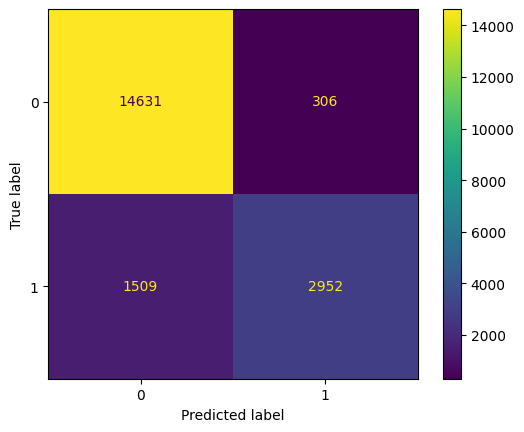

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## **Deep Learning**





In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy


In [ ]:
model = Sequential()
model.add(Dense(104, input_shape=(6,), activation='relu'))
model.add(Dense(72, activation = 'relu'))
model.add(Dense(48, activation = 'relu'))
model.add(Dense(22, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=30, batch_size=32)

Epoch 1/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9012 - loss: 0.3524
Epoch 2/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9040 - loss: 0.3177
Epoch 3/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9051 - loss: 0.3149
Epoch 4/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9051 - loss: 0.3150
Epoch 5/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9050 - loss: 0.3151
Epoch 6/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9072 - loss: 0.3101
Epoch 7/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9063 - loss: 0.3120
Epoch 8/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9050 - loss: 0.3148
Epoch 9/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9061 - loss: 0.3125
Epoch 10/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9045 - loss: 0.3158
Epoch 11/30
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9064 - loss: 0.3114
Epoch 12/30
2425/24

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9628 - loss: 0.1779
Model Accuracy: 90.07%


## Pickle Format

In [ ]:
import pickle
with open("CervicalCancer_Detection_model.pkl","wb")as file:
  pickle.dump(model,file)

# **Conclusion**

In this project, a machine learning approach was used to predict the likelihood of cervical cancer based on various patient risk factors such as age, lifestyle habits, medical history, and sexually transmitted disease information.The dataset was first preprocessed by handling missing values and preparing the features for model training. Several machine learning algorithms were implemented, including Logistic Regression, Decision Tree, Support Vector Classifier (SVC), XGBoost, and Deep Learning models, to compare their predictive performance.

To evaluate the models, techniques such as Confusion Matrix and K-Fold Cross Validation were used to ensure reliable and accurate performance evaluation. Among all the models tested, Logistic Regression achieved the highest accuracy of 91%, making it the most effective model for this dataset.

Finally, the best-performing model was saved in Pickle (.pkl) format, allowing it to be easily reused for future predictions or integrated into applications for real-time cervical cancer risk prediction.